# LSTM Model

This is the final LSTM rerun. The model now receives actual historical demand directly at each sequence timestep instead of receiving 48 repeated lag columns. It uses the same dataset, chronological split, evaluation timestamps and metrics as the baseline and XGBoost notebooks.

Before running the notebook, select **Runtime → Change runtime type → T4 GPU** in Colab.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports and GPU check

In [2]:
from pathlib import Path
import importlib.util
import json
import os
import random
import subprocess
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

if importlib.util.find_spec('keras_tuner') is None:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'keras-tuner'],
        check=True,
    )
import keras_tuner as kt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import callbacks, layers, models, optimizers, regularizers

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow version:', tf.__version__)
print('Keras Tuner version:', kt.__version__)
print('GPU available:', bool(gpus))
print('GPU devices:', gpus)

TensorFlow version: 2.20.0
Keras Tuner version: 1.4.8
GPU available: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load the same `Final.parquet` used by the other models

In [3]:
DATA_PATH = Path(
    '/content/drive/My Drive/NSW_Electricity_Demand/Data/Processed/Data.parquet'
)
OUTPUT_DIR = Path(
    '/content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/LSTM_Final'
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df = df.sort_values('DATETIME').reset_index(drop=True)

# Keep historical demand separate so scaling the inputs does not alter the target.
df['DEMAND_HISTORY'] = df['TOTALDEMAND'].astype('float64')

print('Rows:', f'{len(df):,}')
print('Period:', df['DATETIME'].min(), 'to', df['DATETIME'].max())

Rows: 196,417
Period: 2010-01-03 00:00:00 to 2021-03-18 00:00:00


## 3. Select the LSTM features

The 48-row sequence already contains one full day of history, so separate `Lag_1` to `Lag_48` columns are unnecessary. `DEMAND_HISTORY` lets the final sequence row provide demand from exactly 30 minutes before the prediction target. `FORECASTDEMAND` remains excluded.

In [4]:
target_column = 'TOTALDEMAND'

feature_columns = [
    'DEMAND_HISTORY',
    'TEMPERATURE', 'TEMP2', 'TEMP3',
    'ROLL_MEAN_12', 'ROLL_MEAN_24',
    'ROLL_STD_12', 'ROLL_STD_24',
    'IS_WEEKEND', 'IS_PEAK',
    'HOUR', 'DAY', 'MONTH',
]

missing_features = [
    column for column in feature_columns if column not in df.columns
]
if missing_features:
    raise ValueError(f'Missing LSTM features: {missing_features}')

print('Number of LSTM features:', len(feature_columns))
print('FORECASTDEMAND used as a feature:', 'FORECASTDEMAND' in feature_columns)

Number of LSTM features: 13
FORECASTDEMAND used as a feature: False


## 4. Apply the common chronological split

In [5]:
n = len(df)
test_n = int(0.20 * n)
val_n = int(0.10 * n)

train_end = n - val_n - test_n
val_end = n - test_n

df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:val_end].copy()
df_test = df.iloc[val_end:].copy()

print('Training rows:', f'{len(df_train):,}')
print('Validation rows:', f'{len(df_val):,}')
print('Test rows:', f'{len(df_test):,}')

Training rows: 137,493
Validation rows: 19,641
Test rows: 39,283


## 5. Scale features using training data only

The scaler is fitted only on the training partition, then applied to validation and test data.

In [6]:
feature_scaler = StandardScaler()

df_train.loc[:, feature_columns] = feature_scaler.fit_transform(
    df_train[feature_columns]
)
df_val.loc[:, feature_columns] = feature_scaler.transform(
    df_val[feature_columns]
)
df_test.loc[:, feature_columns] = feature_scaler.transform(
    df_test[feature_columns]
)

/tmp/ipykernel_2819/3173975216.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.58034227  1.58034227  1.58034227 ... -0.63277432 -0.63277432
 -0.63277432]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_train.loc[:, feature_columns] = feature_scaler.fit_transform(
/tmp/ipykernel_2819/3173975216.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.57731388 -0.57731388 -0.57731388 ...  1.73215999  1.73215999
 -0.57731388]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_train.loc[:, feature_columns] = feature_scaler.fit_transform(
/tmp/ipykernel_2819/3173975216.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.66115834 -1.66115834 -1.51669686 ... -0.36100503 -0.36100503
 -

## 6. Create 48-step sequences

Each sample uses the preceding 48 half-hour rows to predict demand in the following interval. Sequences are created separately within each partition, matching the 48-row alignment used by the baseline and XGBoost notebooks.

In [7]:
def make_sequences(frame, features, target, steps=48):
    feature_values = frame[features].to_numpy(dtype='float32')
    target_values = frame[target].to_numpy(dtype='float32')
    timestamps = frame['DATETIME'].reset_index(drop=True)

    X, y = [], []
    for index in range(steps, len(frame)):
        X.append(feature_values[index - steps:index])
        y.append(target_values[index])

    return (
        np.asarray(X, dtype='float32'),
        np.asarray(y, dtype='float32'),
        timestamps.iloc[steps:].reset_index(drop=True),
    )

STEPS = 48

X_train, y_train, train_timestamps = make_sequences(
    df_train, feature_columns, target_column, STEPS
)
X_val, y_val, validation_timestamps = make_sequences(
    df_val, feature_columns, target_column, STEPS
)
X_test, y_test, test_timestamps = make_sequences(
    df_test, feature_columns, target_column, STEPS
)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:', X_val.shape, 'y_val:', y_val.shape)
print('X_test:', X_test.shape, 'y_test:', y_test.shape)
print('First test prediction:', test_timestamps.iloc[0])

# Confirm that the final input timestep contains demand from exactly t-1.
demand_feature_index = feature_columns.index('DEMAND_HISTORY')
latest_demand_from_sequences = (
    X_test[:, -1, demand_feature_index]
    * feature_scaler.scale_[demand_feature_index]
    + feature_scaler.mean_[demand_feature_index]
)
expected_latest_demand = (
    df_test['TOTALDEMAND'].iloc[STEPS - 1:-1].to_numpy()
)
print(
    'Latest-demand alignment correct:',
    np.allclose(latest_demand_from_sequences, expected_latest_demand, atol=0.1),
)

X_train: (137445, 48, 13) y_train: (137445,)
X_val: (19593, 48, 13) y_val: (19593,)
X_test: (39235, 48, 13) y_test: (39235,)
First test prediction: 2018-12-21 15:00:00
Latest-demand alignment correct: True


## 7. Scale the target using training data only

In [8]:
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.reshape(-1, 1)
).ravel()
y_val_scaled = target_scaler.transform(
    y_val.reshape(-1, 1)
).ravel()

def inverse_target(values):
    return target_scaler.inverse_transform(
        np.asarray(values).reshape(-1, 1)
    ).ravel()

## 8. Tune the LSTM with Hyperband

Hyperband searches a small, practical set of LSTM architectures using only the training and validation partitions. The test partition is not used during tuning.

In [10]:
def build_lstm(hp):
    units_1 = hp.Choice('units_1', values=[64, 96, 128])
    units_2 = hp.Choice('units_2', values=[32, 48, 64])
    dropout = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    l2_value = hp.Choice('l2', values=[1e-6, 1e-5, 1e-4])
    learning_rate = hp.Choice(
        'learning_rate', values=[5e-4, 1e-3, 2e-3]
    )

    candidate = models.Sequential([
        layers.Input(shape=(STEPS, len(feature_columns))),
        layers.LSTM(
            units_1,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(l2_value),
        ),
        layers.Dropout(dropout),
        layers.LSTM(
            units_2,
            kernel_regularizer=regularizers.l2(l2_value),
        ),
        layers.Dropout(dropout),
        layers.Dense(1),
    ])

    candidate.compile(
        optimizer=optimizers.Adam(
            learning_rate=learning_rate, clipnorm=1.0
        ),
        loss='mse',
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name='mae'),
            tf.keras.metrics.RootMeanSquaredError(name='rmse'),
        ],
    )
    return candidate

TUNER_DIR = OUTPUT_DIR / 'hyperband_search'
tuner = kt.Hyperband(
    build_lstm,
    objective=kt.Objective('val_loss', direction='min'),
    max_epochs=20,
    factor=3,
    hyperband_iterations=1,
    directory=str(TUNER_DIR),
    project_name='lstm_direct_demand',
    overwrite=False,
    seed=SEED,
)

tuning_early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
)

tuner.search(
    X_train,
    y_train_scaled,
    validation_data=(X_val, y_val_scaled),
    epochs=20,
    batch_size=256,
    shuffle=True,
    callbacks=[tuning_early_stopping],
    verbose=1,
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hyperparameters = {
    name: best_hps.get(name)
    for name in [
        'units_1', 'units_2', 'dropout', 'l2', 'learning_rate'
    ]
}
display(pd.Series(best_hyperparameters, name='Selected value'))
tuner.results_summary(num_trials=10)

with open(
    OUTPUT_DIR / 'lstm_best_hyperparameters.json',
    'w',
) as file:
    json.dump(best_hyperparameters, file, indent=2)

Trial 30 Complete [00h 02m 19s]
val_loss: 0.003186215180903673

Best val_loss So Far: 0.0023122099228203297
Total elapsed time: 00h 29m 27s


,Selected value
units_1,128.000000
units_2,64.000000
dropout,0.100000
l2,0.000001
learning_rate,0.001000


Results summary
Results in /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/LSTM_Final/hyperband_search/lstm_direct_demand
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0016 summary
Hyperparameters:
units_1: 128
units_2: 64
dropout: 0.1
l2: 1e-06
learning_rate: 0.001
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012
Score: 0.0023122099228203297

Trial 0012 summary
Hyperparameters:
units_1: 128
units_2: 64
dropout: 0.1
l2: 1e-06
learning_rate: 0.001
tuner/epochs: 7
tuner/initial_epoch: 3
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0007
Score: 0.003177747130393982

Trial 0029 summary
Hyperparameters:
units_1: 96
units_2: 48
dropout: 0.1
l2: 0.0001
learning_rate: 0.002
tuner/epochs: 20
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.003186215180903673

Trial 0017 summary
Hyperparameters:
units_1: 96
units_2: 32
dropout: 0.2
l2: 1e-06
learning_rate: 0.002
tuner/epochs: 20
tuner/initial_ep

## 9. Train the final model with the selected hyperparameters

In [11]:
model = tuner.hypermodel.build(best_hps)
model.summary()

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

history = model.fit(
    X_train,
    y_train_scaled,
    validation_data=(X_val, y_val_scaled),
    epochs=40,
    batch_size=256,
    # Sequences remain internally ordered; only their training batch order is shuffled.
    shuffle=True,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 48, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,177 (477.25 KB)

 Trainable params: 122,177 (477.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
537/537 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0391 - mae: 0.1344 - rmse: 0.1971 - val_loss: 0.0123 - val_mae: 0.0859 - val_rmse: 0.1099 - learning_rate: 0.0010
Epoch 2/40
537/537 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0115 - mae: 0.0816 - rmse: 0.1064 - val_loss: 0.0068 - val_mae: 0.0622 - val_rmse: 0.0813 - learning_rate: 0.0010
Epoch 3/40
537/537 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0087 - mae: 0.0705 - rmse: 0.0920 - val_loss: 0.0044 - val_mae: 0.0496 - val_rmse: 0.0647 - learning_rate: 0.0010
Epoch 4/40
537/537 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0074 - mae: 0.0645 - rmse: 0.0846 - val_loss: 0.0048 - val_mae: 0.0523 - val_rmse: 0.0678 - learning_rate: 0.0010
Epoch 5/40
537/537 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0065 - mae: 0.0605 - rmse: 0.0795 - val_loss: 0.0037 - val_mae: 0.0456 - val_rmse: 0.0588 - learning_rate: 0.0010
Epoch 6/40
537/537 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0061 - mae: 0.0583 - rmse: 0.0766 - val_loss: 0.003

## 10. Training curve

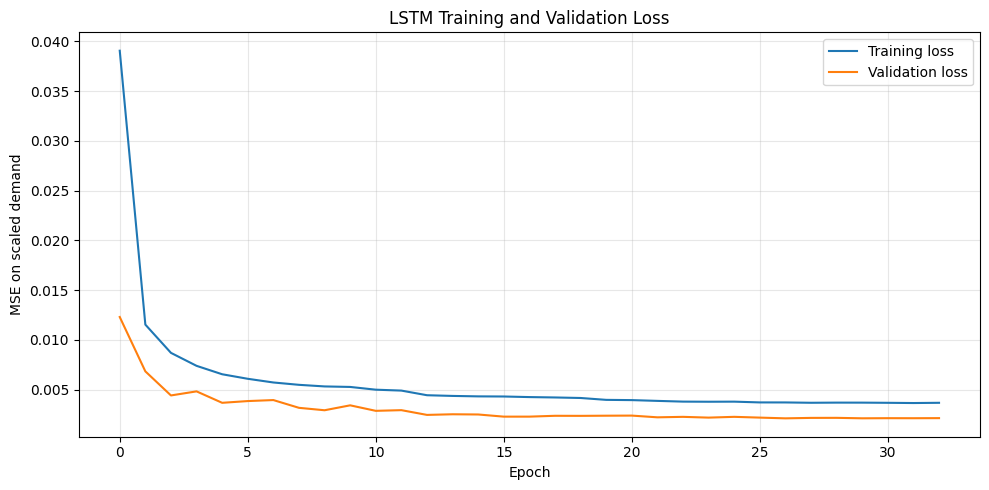

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE on scaled demand')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Predict the test period

In [13]:
y_pred_scaled = model.predict(X_test, verbose=0).ravel()
y_pred = inverse_target(y_pred_scaled)

lstm_predictions = pd.DataFrame({
    'DATETIME': test_timestamps,
    'TOTALDEMAND': y_test,
    'LSTM_Prediction': y_pred,
})

print('LSTM sequence predictions:', f'{len(lstm_predictions):,}')

LSTM sequence predictions: 39,235


## 12. Match the timestamps already saved by baseline and XGBoost

This step ensures that the displayed LSTM metrics use the same observations as the other completed models.

In [14]:
comparison_files = [
    Path('/content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/Baseline/baseline_predictions.parquet'),
    Path('/content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/XGBoost/xgboost_predictions.parquet'),
]

common_timestamps = lstm_predictions[['DATETIME']].copy()
for prediction_file in comparison_files:
    if prediction_file.exists():
        saved_timestamps = pd.read_parquet(
            prediction_file, columns=['DATETIME']
        )
        saved_timestamps['DATETIME'] = pd.to_datetime(
            saved_timestamps['DATETIME']
        )
        common_timestamps = common_timestamps.merge(
            saved_timestamps.drop_duplicates(),
            on='DATETIME',
            how='inner',
        )

lstm_predictions = lstm_predictions.merge(
    common_timestamps.drop_duplicates(),
    on='DATETIME',
    how='inner',
).sort_values('DATETIME').reset_index(drop=True)

print('Common evaluation observations:', f'{len(lstm_predictions):,}')
print('First timestamp:', lstm_predictions['DATETIME'].min())
print('Last timestamp:', lstm_predictions['DATETIME'].max())

Common evaluation observations: 39,235
First timestamp: 2018-12-21 15:00:00
Last timestamp: 2021-03-18 00:00:00


## 13. Evaluate in MW

In [15]:
actual = lstm_predictions['TOTALDEMAND'].to_numpy()
predicted = lstm_predictions['LSTM_Prediction'].to_numpy()
errors = predicted - actual

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = (np.abs(errors) / actual).mean() * 100
r2 = r2_score(actual, predicted)
bias = errors.mean()

lstm_metrics = pd.DataFrame([{
    'Model': 'LSTM',
    'Observations': len(actual),
    'MAE': mae,
    'RMSE': rmse,
    'MAPE': mape,
    'R2': r2,
    'Bias': bias,
}])

display(lstm_metrics.round({
    'MAE': 2, 'RMSE': 2, 'MAPE': 2, 'R2': 4, 'Bias': 2
}))

,Model,Observations,MAE,RMSE,MAPE,R2,Bias
0,LSTM,39235,53.87,71.55,0.7,0.9967,0.83


## 14. Save the model, scalers and predictions

In [16]:
model.save(OUTPUT_DIR / 'lstm_model.keras')
joblib.dump(feature_scaler, OUTPUT_DIR / 'lstm_feature_scaler.joblib')
joblib.dump(target_scaler, OUTPUT_DIR / 'lstm_target_scaler.joblib')
joblib.dump(feature_columns, OUTPUT_DIR / 'lstm_feature_names.joblib')

lstm_predictions.to_parquet(
    OUTPUT_DIR / 'lstm_predictions.parquet', index=False
)
lstm_metrics.to_csv(
    OUTPUT_DIR / 'lstm_test_metrics.csv', index=False
)

history_values = {
    key: [float(value) for value in values]
    for key, values in history.history.items()
}
with open(OUTPUT_DIR / 'lstm_training_history.json', 'w') as file:
    json.dump(history_values, file, indent=2)

print('Saved outputs to:', OUTPUT_DIR)

Saved outputs to: /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/LSTM_Final


## 15. Actual versus predicted demand

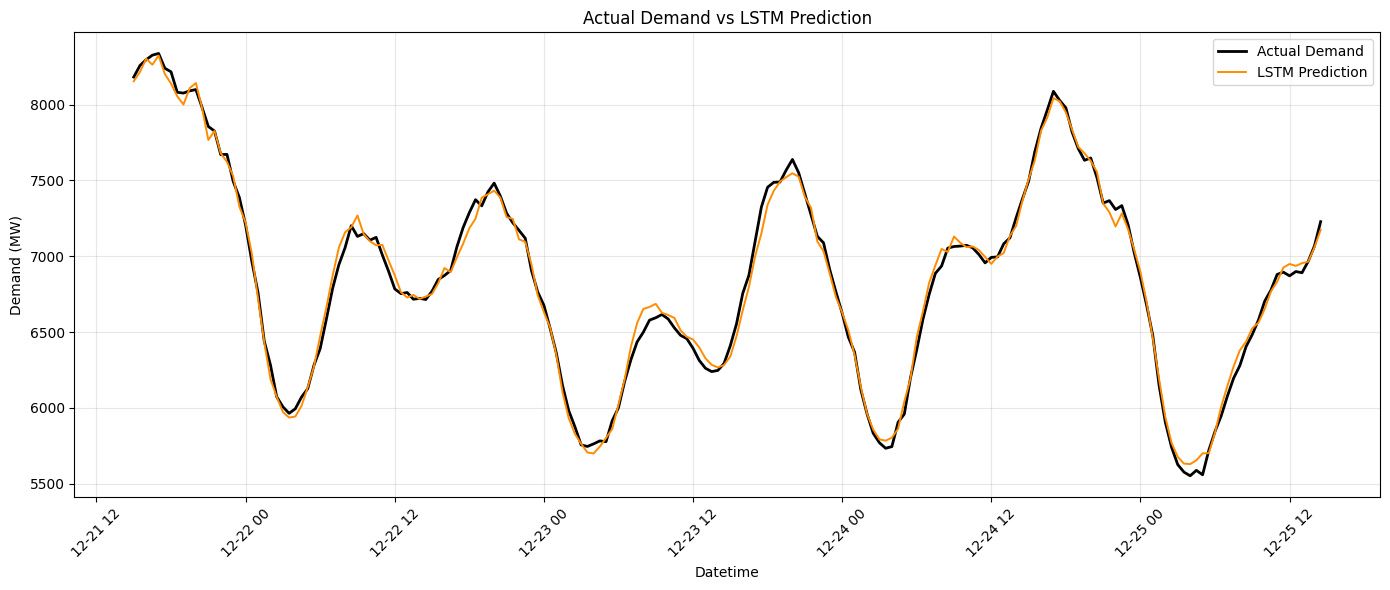

In [18]:
plot_data = lstm_predictions.iloc[:48 * 4]

plt.figure(figsize=(14, 6))
plt.plot(
    plot_data['DATETIME'], plot_data['TOTALDEMAND'],
    label='Actual Demand', color='black', linewidth=2
)
plt.plot(
    plot_data['DATETIME'], plot_data['LSTM_Prediction'],
    label='LSTM Prediction', color='darkorange', linewidth=1.4
)
plt.title('Actual Demand vs LSTM Prediction')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16. Average demand by hour

A single ten-day plot is useful for checking individual predictions, but averaging by hour makes it easier to see whether the model captures the typical daily shape.

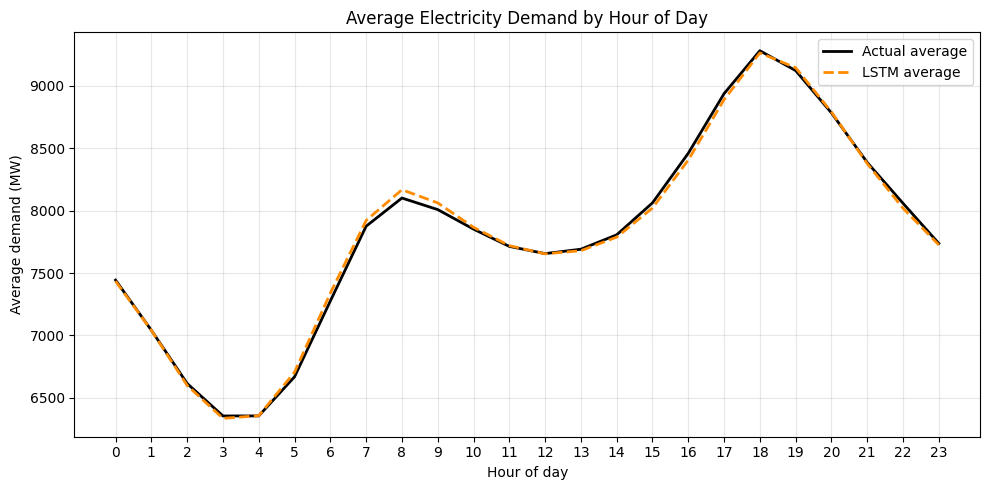

In [19]:
evaluation_data = lstm_predictions.copy()
evaluation_data['HOUR'] = evaluation_data['DATETIME'].dt.hour
evaluation_data['IS_WEEKEND'] = (
    evaluation_data['DATETIME'].dt.dayofweek >= 5
)

hourly_average = (
    evaluation_data
    .groupby('HOUR')[['TOTALDEMAND', 'LSTM_Prediction']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_average['HOUR'], hourly_average['TOTALDEMAND'],
    label='Actual average', color='black', linewidth=2
)
plt.plot(
    hourly_average['HOUR'], hourly_average['LSTM_Prediction'],
    label='LSTM average', color='darkorange', linestyle='--', linewidth=2
)
plt.title('Average Electricity Demand by Hour of Day')
plt.xlabel('Hour of day')
plt.ylabel('Average demand (MW)')
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Weekday and weekend behaviour

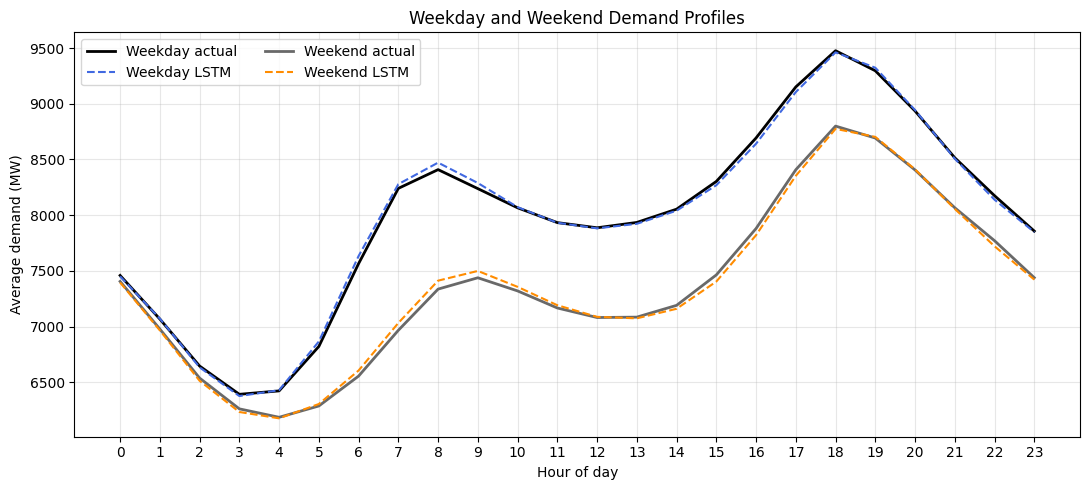

In [20]:
day_type_average = (
    evaluation_data
    .groupby(['IS_WEEKEND', 'HOUR'])[['TOTALDEMAND', 'LSTM_Prediction']]
    .mean()
    .reset_index()
)

weekday = day_type_average[~day_type_average['IS_WEEKEND']]
weekend = day_type_average[day_type_average['IS_WEEKEND']]

plt.figure(figsize=(11, 5))
plt.plot(weekday['HOUR'], weekday['TOTALDEMAND'],
         label='Weekday actual', color='black', linewidth=2)
plt.plot(weekday['HOUR'], weekday['LSTM_Prediction'],
         label='Weekday LSTM', color='royalblue', linestyle='--')
plt.plot(weekend['HOUR'], weekend['TOTALDEMAND'],
         label='Weekend actual', color='dimgray', linewidth=2)
plt.plot(weekend['HOUR'], weekend['LSTM_Prediction'],
         label='Weekend LSTM', color='darkorange', linestyle='--')
plt.title('Weekday and Weekend Demand Profiles')
plt.xlabel('Hour of day')
plt.ylabel('Average demand (MW)')
plt.xticks(range(24))
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Performance across seasons

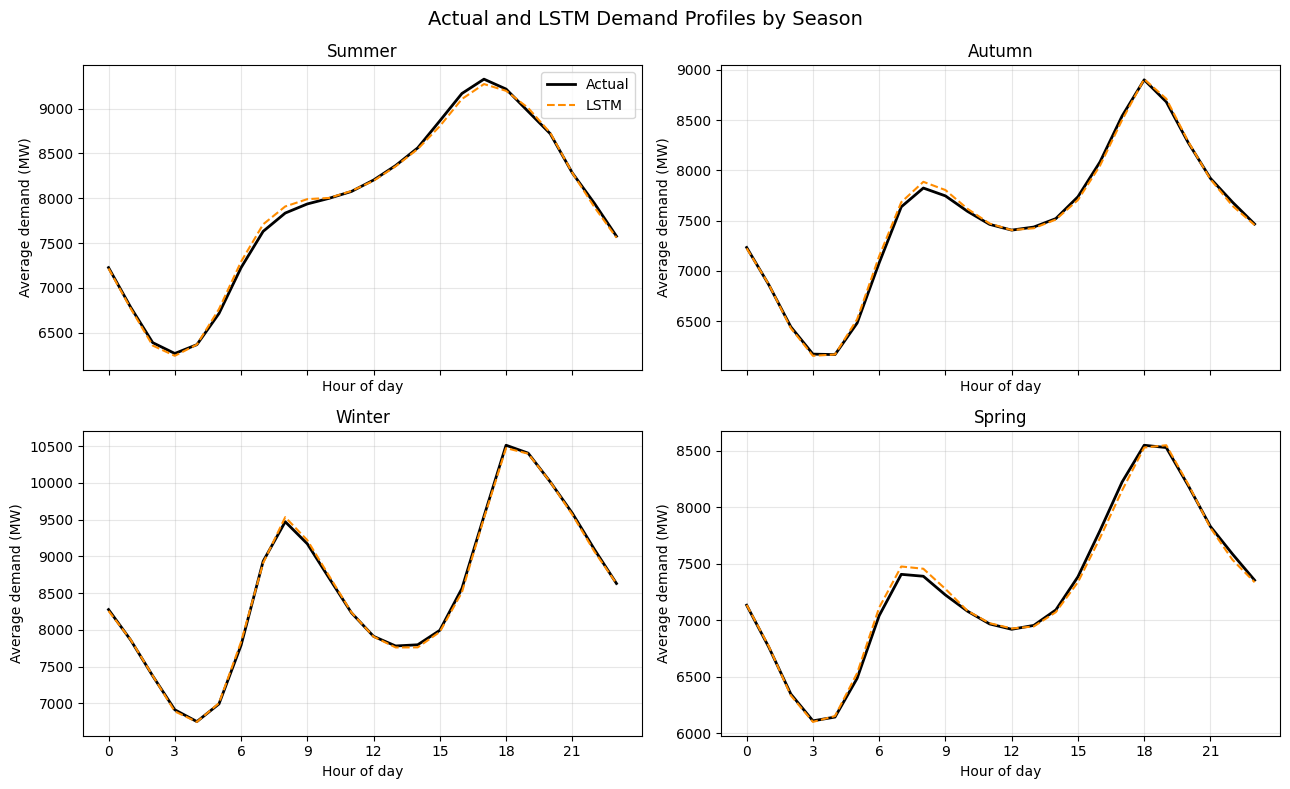

In [21]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    if month in [3, 4, 5]:
        return 'Autumn'
    if month in [6, 7, 8]:
        return 'Winter'
    return 'Spring'

evaluation_data['SEASON'] = (
    evaluation_data['DATETIME'].dt.month.map(get_season)
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

for axis, season in zip(axes.ravel(), ['Summer', 'Autumn', 'Winter', 'Spring']):
    seasonal = (
        evaluation_data[evaluation_data['SEASON'] == season]
        .groupby('HOUR')[['TOTALDEMAND', 'LSTM_Prediction']]
        .mean()
    )
    axis.plot(seasonal.index, seasonal['TOTALDEMAND'],
              label='Actual', color='black', linewidth=2)
    axis.plot(seasonal.index, seasonal['LSTM_Prediction'],
              label='LSTM', color='darkorange', linestyle='--')
    axis.set_title(season)
    axis.set_xlabel('Hour of day')
    axis.set_ylabel('Average demand (MW)')
    axis.set_xticks(range(0, 24, 3))
    axis.grid(alpha=0.3)

axes[0, 0].legend()
fig.suptitle('Actual and LSTM Demand Profiles by Season', fontsize=14)
plt.tight_layout()
plt.show()

## 19. Temperature and residual analysis

The EDA showed a nonlinear relationship between temperature and demand. Here I check whether model error also changes across temperature conditions.

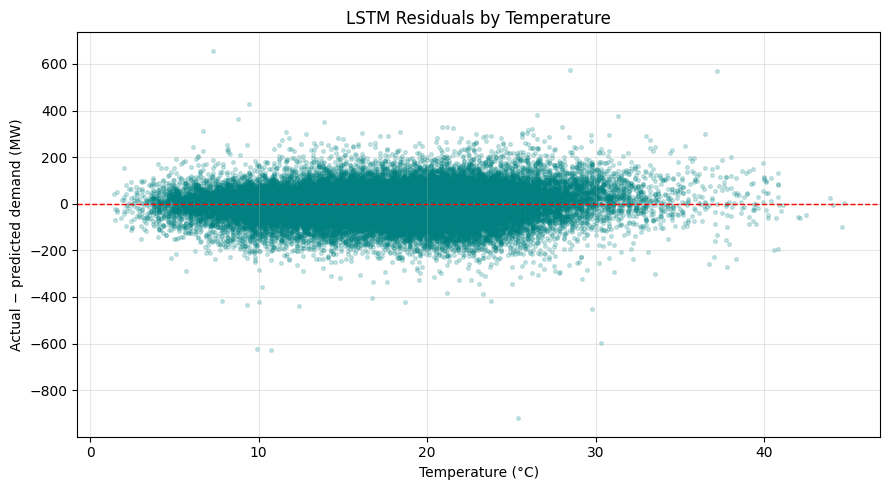

In [22]:
temperature_context = df[['DATETIME', 'TEMPERATURE']].copy()
evaluation_data = evaluation_data.merge(
    temperature_context, on='DATETIME', how='left'
)
evaluation_data['RESIDUAL'] = (
    evaluation_data['TOTALDEMAND'] - evaluation_data['LSTM_Prediction']
)
evaluation_data['TEMP_GROUP'] = pd.cut(
    evaluation_data['TEMPERATURE'],
    bins=[-np.inf, 10, 20, 30, np.inf],
    labels=['Cold (<10°C)', 'Mild (10–20°C)',
            'Warm (20–30°C)', 'Hot (>30°C)'],
)

plt.figure(figsize=(9, 5))
plt.scatter(
    evaluation_data['TEMPERATURE'], evaluation_data['RESIDUAL'],
    s=7, alpha=0.2, color='teal'
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('LSTM Residuals by Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Actual − predicted demand (MW)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
temperature_metrics = []

for temperature_group, group in evaluation_data.groupby(
    'TEMP_GROUP', observed=True
):
    group_actual = group['TOTALDEMAND'].to_numpy()
    group_predicted = group['LSTM_Prediction'].to_numpy()
    group_error = group_predicted - group_actual

    temperature_metrics.append({
        'Temperature range': str(temperature_group),
        'Observations': len(group),
        'MAE': mean_absolute_error(group_actual, group_predicted),
        'RMSE': np.sqrt(mean_squared_error(group_actual, group_predicted)),
        'MAPE': (np.abs(group_error) / group_actual).mean() * 100,
        'Bias': group_error.mean(),
    })

temperature_metrics = pd.DataFrame(temperature_metrics)
display(temperature_metrics.round({
    'MAE': 2, 'RMSE': 2, 'MAPE': 2, 'Bias': 2
}))

temperature_metrics.to_csv(
    OUTPUT_DIR / 'lstm_temperature_metrics.csv', index=False
)

,Temperature range,Observations,MAE,RMSE,MAPE,Bias
0,Cold (<10°C),3875,48.05,66.45,0.61,4.800000
1,Mild (10–20°C),20117,50.89,67.21,0.67,2.780000
2,Warm (20–30°C),14418,58.72,77.10,0.75,-1.360000
3,Hot (>30°C),825,69.18,93.40,0.70,-27.139999


## 20. Permutation feature importance

For each feature I shuffle that feature across a sample of test sequences and measure the increase in MAE. A larger increase means the model depended more heavily on that feature. A sample is used so this analysis remains practical in Colab.

In [24]:
IMPORTANCE_SAMPLE_SIZE = min(2000, len(X_test))
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(
    len(X_test), size=IMPORTANCE_SAMPLE_SIZE, replace=False
)

X_importance = X_test[sample_indices].copy()
y_importance_scaled = target_scaler.transform(
    y_test[sample_indices].reshape(-1, 1)
).ravel()
base_prediction_scaled = model.predict(
    X_importance, verbose=0
).ravel()
base_mae_scaled = mean_absolute_error(
    y_importance_scaled, base_prediction_scaled
)

importance_rows = []
for feature_index, feature_name in enumerate(feature_columns):
    shuffled = X_importance.copy()
    order = rng.permutation(IMPORTANCE_SAMPLE_SIZE)
    shuffled[:, :, feature_index] = shuffled[order, :, feature_index]
    shuffled_prediction = model.predict(shuffled, verbose=0).ravel()
    shuffled_mae = mean_absolute_error(
        y_importance_scaled, shuffled_prediction
    )
    importance_rows.append({
        'Feature': feature_name,
        'Increase_in_scaled_MAE': shuffled_mae - base_mae_scaled,
    })

permutation_importance = (
    pd.DataFrame(importance_rows)
    .sort_values('Increase_in_scaled_MAE', ascending=False)
    .reset_index(drop=True)
)

display(permutation_importance.head(15))
permutation_importance.to_csv(
    OUTPUT_DIR / 'lstm_permutation_importance.csv', index=False
)

,Feature,Increase_in_scaled_MAE
0,DEMAND_HISTORY,1.057817
1,ROLL_MEAN_12,0.058601
2,IS_PEAK,0.057429
3,HOUR,0.046004
4,ROLL_MEAN_24,0.020779
5,MONTH,0.017739
6,ROLL_STD_12,0.015047
7,ROLL_STD_24,0.013452
8,TEMP2,0.010593
9,TEMPERATURE,0.007701


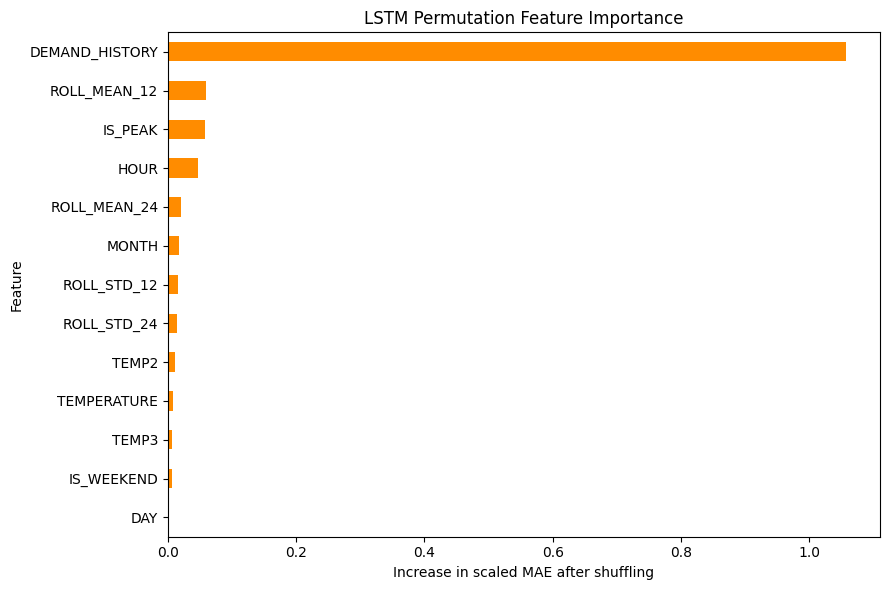

In [25]:
importance_plot = (
    permutation_importance.head(15)
    .sort_values('Increase_in_scaled_MAE')
)

importance_plot.plot(
    kind='barh',
    x='Feature',
    y='Increase_in_scaled_MAE',
    figsize=(9, 6),
    legend=False,
    color='darkorange',
)
plt.title('LSTM Permutation Feature Importance')
plt.xlabel('Increase in scaled MAE after shuffling')
plt.tight_layout()
plt.show()

## 21. What will be used in the final comparison

The overall metric table and `lstm_predictions.parquet` are the official LSTM outputs. The remaining charts explain when the model performs well, where its errors increase and which inputs matter most. The final comparison notebook will recalculate all model metrics after joining their predictions by `DATETIME`.